In [1]:
import os
import pandas as pd 
import numpy as np 

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.ortho_proj_hatz import *

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns 

%matplotlib inline

In [3]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
# waiting = waiting[waiting != 108.0]
contam_data = 108.

bw = 5.0
kernel_type = 'gaussian_poly2'
xlimit = (1., 210.)
plot_pts_cnt = 3000
base_density = BasedenGamma(waiting, 36., 2.)

label_fontsize = 20
label_fontsize = 20

es_folder = (f'../data/data=geyser-waiting-EarlyStoppingSM-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
             f'entire-RKHS')

In [34]:
iternum_list = [0, 1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 
                1500, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000, 30000, 40000]# , 50000]#, 60000, 70000, 80000, 90000]#, 100000]

In [35]:
new_data = np.load(es_folder + f'/new_data.npy')

In [36]:
index = np.argmin(np.abs(new_data - 108))

In [37]:
denvals_108 = []

for iternum in iternum_list: 
    denvals = np.load(es_folder + f'/iter_num={iternum}-densityvals-newdata.npy')
    denvals_108.append(denvals[index])

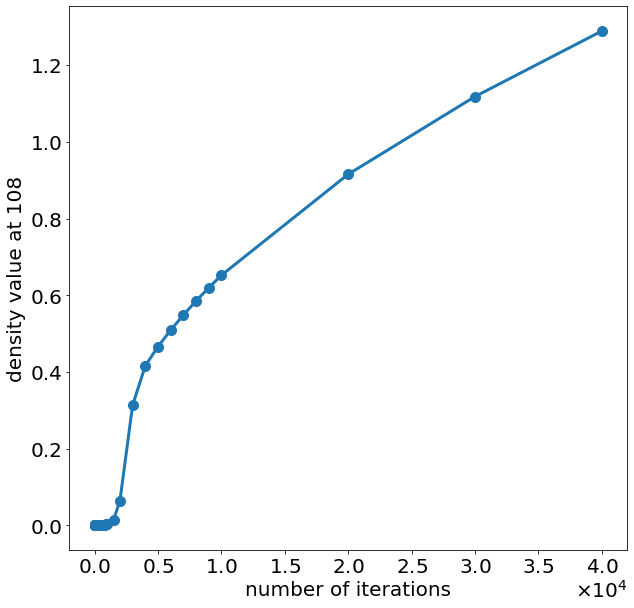

In [66]:
fig, ax = plt.subplots(1, 1, figsize = (10, 10))
ax.plot(iternum_list, denvals_108, color = 'tab:blue', linewidth = 3.0)
ax.plot(iternum_list, denvals_108, color = 'tab:blue', marker = 'o', markersize = 10)
ax.set_xlabel('number of iterations', fontsize = label_fontsize)
ax.set_ylabel('density value at 108', fontsize = label_fontsize)
ax.tick_params('both', labelsize = label_fontsize)
ax.ticklabel_format(style = 'sci', axis = 'x', scilimits = (0, 0), useMathText = True)
ax.xaxis.get_offset_text().set_fontsize(label_fontsize)

plt.savefig(f'../plots/density-at-108-vs-number-iterations-Gamma-{base_density.a}-{base_density.scale}.pdf', 
            bbox_inches = 'tight')

In [42]:
pen_folder = (f'../data/data=geyser-waiting-PenSM-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
             f'entire-RKHS')

In [50]:
log_lambda_list = np.arange(-13.5, 0.5, 0.5)
denvals_108_pen = []

for log_lambda in log_lambda_list: 
    denvals = np.load(pen_folder + f'/logpenparam={log_lambda}-densityvals-newdata.npy')
    denvals_108_pen.append(denvals[index])

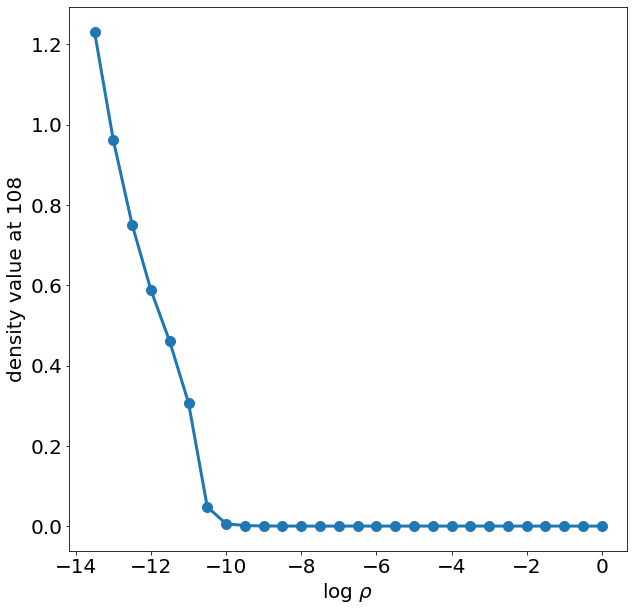

In [67]:
plt.figure(figsize = (10, 10))
plt.plot(log_lambda_list, denvals_108_pen, color = 'tab:blue', linewidth = 3.0)
plt.plot(log_lambda_list, denvals_108_pen, color = 'tab:blue', marker = 'o', markersize = 10)
plt.xlabel(r'$\log \ \rho$', fontsize = label_fontsize)
plt.ylabel('density value at 108', fontsize = label_fontsize)
plt.tick_params('both', labelsize = label_fontsize)

plt.savefig(f'../plots/density-at-108-vs-log-penalty-Gamma-{base_density.a}-{base_density.scale}.pdf', 
            bbox_inches = 'tight')